In [ ]:
%pip install qiskit
%pip install pylatexenc
%pip install qiskit-aer
%pip install numpy

Bell inequality -- 2.8432147562582344 : Bell violation upheld!

Key: -----------------------------------
0010010001101000010111100111011001110101
1111101010110010101010110111000011101010
011110111111010
----------------------------------------



/usr/local/lib/python3.12/dist-packages/qiskit/circuit/quantumcircuit.py:4022: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


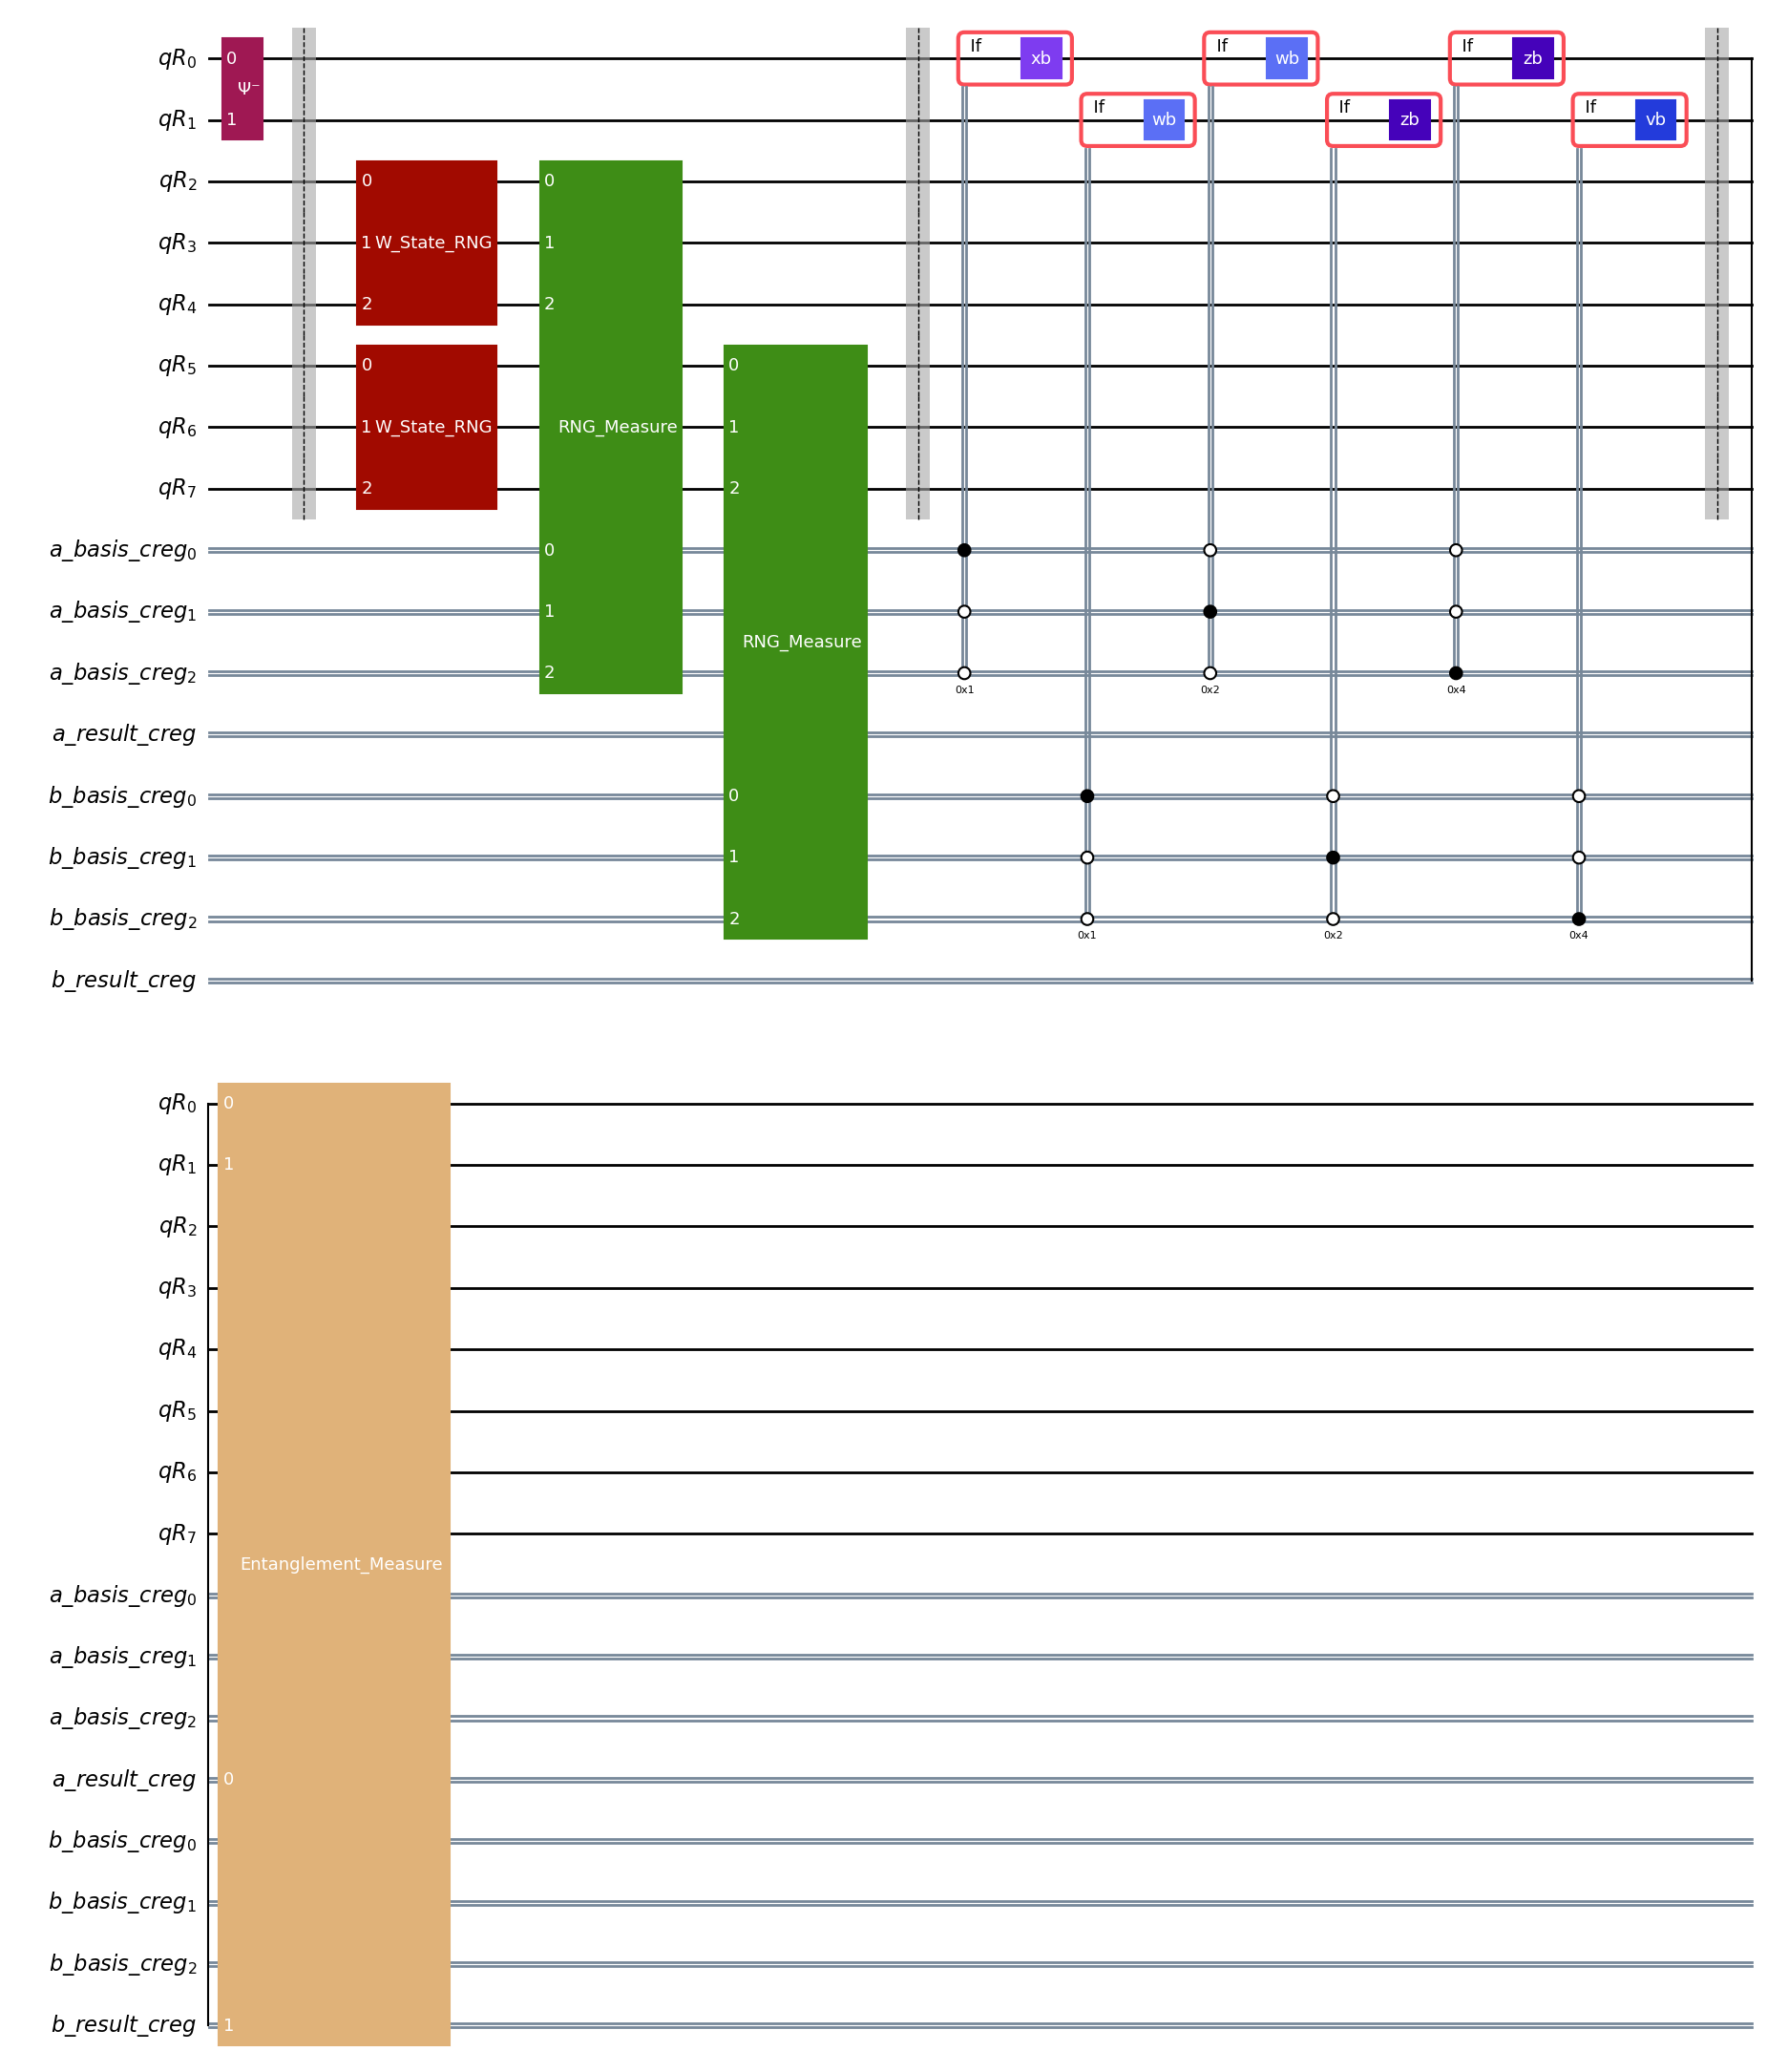

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.converters import circuit_to_gate, circuit_to_instruction
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import UnitaryGate
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram

import numpy as np
from IPython.display import display

#------------------#
#-----2778793s-----#
#------------------#

# N_RANDOM_BITS is effectively fixed to 3 for this specific implementation
# due to the use of the 3-qubit W-state RNG and the corresponding basis picker.
N_RANDOM_BITS = 3
KEY_LENGTH = 90

EPSILON = 2 * (2/np.sqrt(2 * KEY_LENGTH)) # Threshold for success, depending on key length

DIAGRAM_FLAG = True
AS_GATES_AND_INSTRUCTIONS = True # Displays the diagram as integrated circuits, or as individual components
VERBOSE_FLAG = False # For printing all the results of every shot (can get very long!)

# The aim of the assignment is to simulate the Ekert91 key distribution protocol.

quantumRegister = QuantumRegister(2 + (2 * N_RANDOM_BITS), 'qR')

alice_basis_creg = ClassicalRegister(N_RANDOM_BITS, 'a_basis_creg')
alice_result_creg = ClassicalRegister(1, 'a_result_creg')
bob_basis_creg = ClassicalRegister(N_RANDOM_BITS, 'b_basis_creg')
bob_result_creg = ClassicalRegister(1, 'b_result_creg')

ekert = QuantumCircuit(quantumRegister, alice_basis_creg, alice_result_creg, bob_basis_creg, bob_result_creg)

# Matrix definitons

X_basis = np.array([[1,1],[1,-1]]) / np.sqrt(2)
Z_basis = np.array([[1,0],[0,1]])
W_basis = np.array([[np.cos(np.pi/8),np.sin(np.pi/8)],[-np.sin(np.pi/8),np.cos(np.pi/8)]])
V_basis = np.array([[np.cos(np.pi/8),-np.sin(np.pi/8)],[np.sin(np.pi/8),np.cos(np.pi/8)]])

x_basis = UnitaryGate(X_basis, label='xb')
z_basis = UnitaryGate(Z_basis, label='zb')
w_basis = UnitaryGate(W_basis, label='wb')
v_basis = UnitaryGate(V_basis, label='vb')

ALICE_BASES = [x_basis, w_basis, z_basis]
BOB_BASES = [w_basis, z_basis, v_basis]

# Helpers

def get_n_bit_slice_at_k(n, k):
    return list(range(2 + (2* N_RANDOM_BITS)))[2+k*n:2+(k+1)*n]

custom_style = {
    'displaycolor' : {
        'Φ⁻' : '#700733',
        'xb' : '#7e3cf0',
        'zb' : '#4502ba',
        'wb': '#5b6ff5',
        'vb': '#233bdb',
        'W_State_RNG' : '#A10A00',
        'RNG_Measure' : '#3E8D16',
        'Entanglement_Measure' : '#e0b279'
    }
}

def get_data(qc, shots):
  backend = GenericBackendV2(num_qubits=qc.qregs[0].size, control_flow=True)
  compiled = transpile(qc, backend)
  job_sim = backend.run(compiled, shots=np.ceil((9/2) * shots) , memory=True)
  result_sim = job_sim.result()
  bitstring_data = result_sim.get_memory()
  return np.array([row.split(" ") for row in bitstring_data])[...,::-1]

def map_bit_meas(m):
  if m not in ('0','1'):
    raise ValueError('only \'0\' or \'1\' are possible inputs')
  if m == '1':
    return -1
  return 1

def evaluate_nth_result(param):

  def do_nothing(exp_t, key, a_meas, b_meas):
    return exp_t, key

  def update_expected_tracker(exp_t, key, a_meas, b_meas):
    a_meas, b_meas = map_bit_meas(a_meas), map_bit_meas(b_meas)
    exp_t[param]['sum'] += (a_meas * b_meas)
    exp_t[param]['len'] += 1
    return exp_t, key

  def update_key(exp_t, key, a_meas, b_meas):
    key.append(str(a_meas)) # Bob will just invert his bit to get the same as Alice
    return exp_t, key

  if param in ('XcrossW', 'XcrossV', 'ZcrossW', 'ZcrossV'):
    return update_expected_tracker
  elif param in ('key'):
    return update_key
  else:
    return do_nothing

# IMPORTANT: Index via Alice -> Bob!
instruction_manual = {
    '001' : {
        '001' : evaluate_nth_result('XcrossW'),
        '010' : evaluate_nth_result('ignore'),
        '100' : evaluate_nth_result('XcrossV')
    },
    '010' : {
        '001' : evaluate_nth_result('key'),
        '010' : evaluate_nth_result('ignore'),
        '100' : evaluate_nth_result('ignore')
    },
    '100' : {
        '001' : evaluate_nth_result('ZcrossW'),
        '010' : evaluate_nth_result('key'),
        '100' : evaluate_nth_result('ZcrossV')
    }
}

def debug(a,b, aval, bval):
  sum = '-1' if aval != bval else '+1'
  if a not in ('001','010','100') or b not in ('001','010','100'):
    return 'ERROR: Decoherence'
  elif (a == '010' and b == '001') or (a == '100' and b == '010'):
    return 'Key'
  elif (a == '001' and b == '001'):
    return f'XcrossW [{sum}]'
  elif (a == '001' and b == '100'):
    return f'XcrossV [{sum}]'
  elif (a == '100' and b == '001'):
    return f'ZcrossW [{sum}]'
  elif (a == '100' and b == '100'):
    return f'ZcrossV [{sum}]'
  else:
    return 'ignore'

def key_pprint(key):
  print('Key: -----------------------------------')
  for i, ch in enumerate(key):
    print(f'{'\n' if (i % 40 == 0 and not i == 0) else ''}{ch}',end='')
  print()
  print('----------------------------------------')

def calculate_bell_inequality(exp_t):
  result = 0
  for k, v in exp_t.items():
    result += ((-1) ** (k == 'XcrossV') * (v['sum'] / v['len']))
  return np.abs(result)

def determine_bell_violation_tolerance(bv):
  if bv >= ((2*np.sqrt(2)) - EPSILON):
    return True
  else:
    return False

# -- Component Definitions --

# Initial Entanglement
def get_psi_():
    psi_circuit = QuantumCircuit(2)
    psi_circuit.h(1)
    psi_circuit.cx(1,0)
    psi_circuit.x(1)
    psi_circuit.z(1)
    return circuit_to_gate(psi_circuit,label='Ψ⁻') if AS_GATES_AND_INSTRUCTIONS else psi_circuit

# RNG

# https://medium.com/the-quantastic-journal/creation-of-multipartite-entangled-ghz-and-w-states-with-qutip-examples-e6e95e9d8be7

def get_w_state_rng_3_qubits():
    # This function specifically generates a 3-qubit W-state (1/√3)(|100⟩ + |010⟩ + |001⟩).
    # When measured, it produces one of the three one-hot bit patterns (001, 010, 100)
    # with approximately equal probability. These patterns are then used by the basis picker.
    theta = 2 * np.arccos(1/np.sqrt(3))
    qr = QuantumCircuit(3)
    qr.ry(theta, 0)
    qr.ch(0,1)
    qr.cx(1,2)
    qr.cx(0,1)
    qr.x(0)
    return circuit_to_gate(qr,label='W_State_RNG') if AS_GATES_AND_INSTRUCTIONS else qr

# RNG Measurer
def measure_RNG(n_bits, creg):
    mqr = QuantumCircuit(QuantumRegister(n_bits), creg)
    mqr.measure(range(n_bits),range(n_bits))
    return circuit_to_instruction(mqr, label='RNG_Measure') if AS_GATES_AND_INSTRUCTIONS else mqr

# Basis Picker

def pick_a_basis(basis_ops, creg):
    # Alice bit patterns:
    # |001> = X, |010> = W, |100> = Z
    # Bob bit patterns:
    # |001> = W, |010> = Z, |100> = V
    pab = QuantumCircuit(QuantumRegister(1), creg)
    expected_creg_size = 3
    if creg.size != expected_creg_size:
        raise ValueError(f"Classical register size must be {expected_creg_size} for this basis picker, but got {creg.size}")

    BIT_PATTERN_0 = 1
    BIT_PATTERN_1 = 2
    BIT_PATTERN_2 = 4

    with pab.if_test((creg, BIT_PATTERN_0)):
      pab.append(basis_ops[0], [0])
    with pab.if_test((creg, BIT_PATTERN_1)):
      pab.append(basis_ops[1], [0])
    with pab.if_test((creg, BIT_PATTERN_2)):
      pab.append(basis_ops[2], [0])
    return pab

# Measure Out
def measure_out():
    mo = QuantumCircuit(2,2)
    mo.measure(range(2),range(2))
    return circuit_to_instruction(mo, label='Entanglement_Measure') if AS_GATES_AND_INSTRUCTIONS else mo

# -- Circuit Construction --

ekert.compose(get_psi_(),
              qubits=[0,1],
              inplace=True)

ekert.barrier()

ekert.compose(get_w_state_rng_3_qubits(),
              qubits=get_n_bit_slice_at_k(N_RANDOM_BITS,0),
              inplace=True)

ekert.compose(get_w_state_rng_3_qubits(),
              qubits=get_n_bit_slice_at_k(N_RANDOM_BITS,1),
              inplace=True)

ekert.compose(measure_RNG(N_RANDOM_BITS, alice_basis_creg),
              qubits=get_n_bit_slice_at_k(N_RANDOM_BITS,0),
              clbits=alice_basis_creg,
              inplace=True)

ekert.compose(measure_RNG(N_RANDOM_BITS, bob_basis_creg),
              qubits=get_n_bit_slice_at_k(N_RANDOM_BITS,1),
              clbits=bob_basis_creg,
              inplace=True)

ekert.barrier()

ekert.compose(pick_a_basis(ALICE_BASES, alice_basis_creg),
              qubits=[0],
              clbits=alice_basis_creg,
              inplace=True)

ekert.compose(pick_a_basis(BOB_BASES, bob_basis_creg),
              qubits=[1],
              clbits=bob_basis_creg,
              inplace=True)

ekert.barrier()

ekert.compose(measure_out(),
             qubits=[0,1],
             clbits=[alice_result_creg[0], bob_result_creg[0]],
             inplace=True)



# -- Run and Validate Statistics --

expectation_tracker = {
    'XcrossW' : {
        'sum' : 0,
        'len' : 0
    },
    'XcrossV' : {
        'sum' : 0,
        'len' : 0
    },
    'ZcrossW' : {
        'sum' : 0,
        'len' : 0
    },
    'ZcrossV' : {
        'sum' : 0,
        'len' : 0
    }
}

key = []

while len(key) < KEY_LENGTH:
  # This Data is ordered:
  # AliceBasisChoice|AlicePairResult|BobBasisChoice|BobPairResult
  results = get_data(ekert, KEY_LENGTH)

  for row in results:
    a_basis, a_meas, b_basis, b_meas = row
    if VERBOSE_FLAG:
      print(f'{row} -- {debug(a_basis, b_basis, a_meas, b_meas)}')
    try:
      parties_compare_results = instruction_manual[a_basis][b_basis]
    except KeyError:
      parties_compare_results = evaluate_nth_result('ignore')

    expectation_tracker, key = parties_compare_results(expectation_tracker, key, a_meas, b_meas)

  bell_violation = calculate_bell_inequality(expectation_tracker)
  did_violate = determine_bell_violation_tolerance(bell_violation)

print()
print(f'Bell inequality -- {bell_violation} : {'Bell violation upheld!' if did_violate else 'Hidden variable detected!'}')
print()

key_pprint(key)
print()

if DIAGRAM_FLAG:
  fig = ekert.draw('mpl', cregbundle=True, style=custom_style)
  display(fig)

# This notebook is for a simulation of the protocol without an attacker.